# Cross Validation

## Setup

In [1]:
# imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeavePOut, LeaveOneOut, cross_validate

In [2]:
# create a classification dataset
X,y = make_classification(n_samples=50, 
                          n_features=10, 
                          n_informative=5, 
                          n_redundant=2, 
                          n_classes=2, 
                          weights=[0.4,0.6],
                          random_state=42)

In [3]:
# initialize classifier
model = DecisionTreeClassifier(max_depth=10, random_state=42)

## Leave p Out CV

In [4]:
# initialise cv instance
lpo = LeavePOut(4)
print("Number of splits: ",lpo.get_n_splits(X))

Number of splits:  230300


In [5]:
%%time
# iterate through each split and evaluate
y_true, y_pred = [], []
for train_idx, test_idx in lpo.split(X):
    #extract train & test sets
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    #fit the model
    model.fit(X_train,y_train)
    #store results
    y_true.extend(list(y_test))
    y_pred.extend(list(model.predict(X_test)))

CPU times: user 1min 16s, sys: 267 ms, total: 1min 16s
Wall time: 1min 16s


In [6]:
print(f'accuracy score: {accuracy_score(y_true,y_pred):.2f}')
print(f'precision score: {precision_score(y_true,y_pred):.2f}')
print(f'recall score: {recall_score(y_true,y_pred):.2f}')
print(f'f1 score: {f1_score(y_true,y_pred):.2f}')

accuracy score: 0.62
precision score: 0.69
recall score: 0.68
f1 score: 0.69


## Leave One Out CV

In [7]:
# initialise cv instance
loo = LeaveOneOut()
print("Number of splits: ",loo.get_n_splits(X))

Number of splits:  50


In [8]:
%%time
# iterate through each split and evaluate
y_true, y_pred = [], []
for train_idx, test_idx in loo.split(X):
    #extract train & test sets
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    #fit the model
    model.fit(X_train,y_train)
    #store results
    y_true.extend(list(y_test))
    y_pred.extend(list(model.predict(X_test)))

CPU times: user 49.1 ms, sys: 4.3 ms, total: 53.4 ms
Wall time: 52.9 ms


In [9]:
print(f'accuracy score: {accuracy_score(y_true,y_pred):.2f}')
print(f'precision score: {precision_score(y_true,y_pred):.2f}')
print(f'recall score: {recall_score(y_true,y_pred):.2f}')
print(f'f1 score: {f1_score(y_true,y_pred):.2f}')

accuracy score: 0.66
precision score: 0.71
recall score: 0.73
f1 score: 0.72


## K-Fold CV

In [10]:
%%time
# define the scoring metrics
scoring_metrics = {'accuracy' : make_scorer(accuracy_score), 
                   'precision': make_scorer(precision_score),
                   'recall': make_scorer(recall_score),
                   'f1': make_scorer(f1_score)}
                   
# run k-fold cross validation
dcScores = cross_validate(model, X, y, cv=10, scoring=scoring_metrics)

CPU times: user 50.3 ms, sys: 2.75 ms, total: 53.1 ms
Wall time: 52.1 ms


In [11]:
# report results
print(f"Mean accuracy: {np.mean(dcScores['test_accuracy']):.2f}")
print(f"Mean precision: {np.mean(dcScores['test_precision']):.2f}")
print(f"Mean recall: {np.mean(dcScores['test_recall']):.2f}")
print(f"Mean f1: {np.mean(dcScores['test_f1']):.2f}")

Mean accuracy: 0.68
Mean precision: 0.69
Mean recall: 0.83
Mean f1: 0.74


## Time Series CV

In [12]:
# time series addtional imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import get_rdataset

In [13]:
# load dataset
data = get_rdataset("AirPassengers", "datasets").data

# create proper monthly dates
data["Month"] = pd.date_range(
    start="1949-01-01",
    periods=len(data),
    freq="MS"
)

data = data.set_index("Month")
data.index.freq = "MS"

y = data["value"]

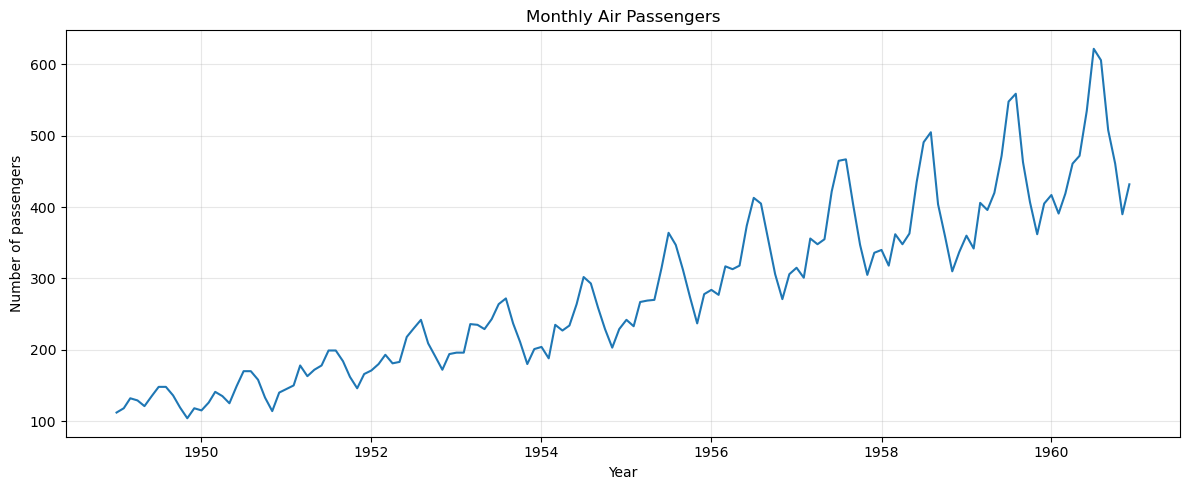

In [14]:
# plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(y.index, y.values)

ax.set_title("Monthly Air Passengers")
ax.set_xlabel("Year")
ax.set_ylabel("Number of passengers")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# time-series cross-validation
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=12
)

print("Number of observations:", len(y))
print("Number of CV folds:", tscv.n_splits)

Number of observations: 144
Number of CV folds: 5


In [16]:
# fit and evaluate SARIMA on each CV fold
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

fold_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(y), start=1):

    # get training and test data
    train = y.iloc[train_idx]
    test = y.iloc[test_idx]

    # fit SARIMA model
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order
    )
    fitted_model = model.fit(disp=False, maxiter=200)

    # forecast on the test period
    forecast = fitted_model.forecast(
        steps=len(test)
    )

    # calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(test, forecast)
    )

    # store results
    fold_results.append({
        "fold": fold,
        "train_start": train.index[0],
        "train_end": train.index[-1],
        "test_start": test.index[0],
        "test_end": test.index[-1],
        "rmse": rmse,
        "test": test,
        "forecast": forecast
    })

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.2f}"
    )

Fold 1: RMSE = 9.98
Fold 2: RMSE = 15.35
Fold 3: RMSE = 19.94
Fold 4: RMSE = 46.08
Fold 5: RMSE = 21.19


In [17]:
# overall performance
rmse_scores = [
    result["rmse"]
    for result in fold_results
]
print(f"Mean CV RMSE: {np.mean(rmse_scores):.2f}")

Mean CV RMSE: 22.51


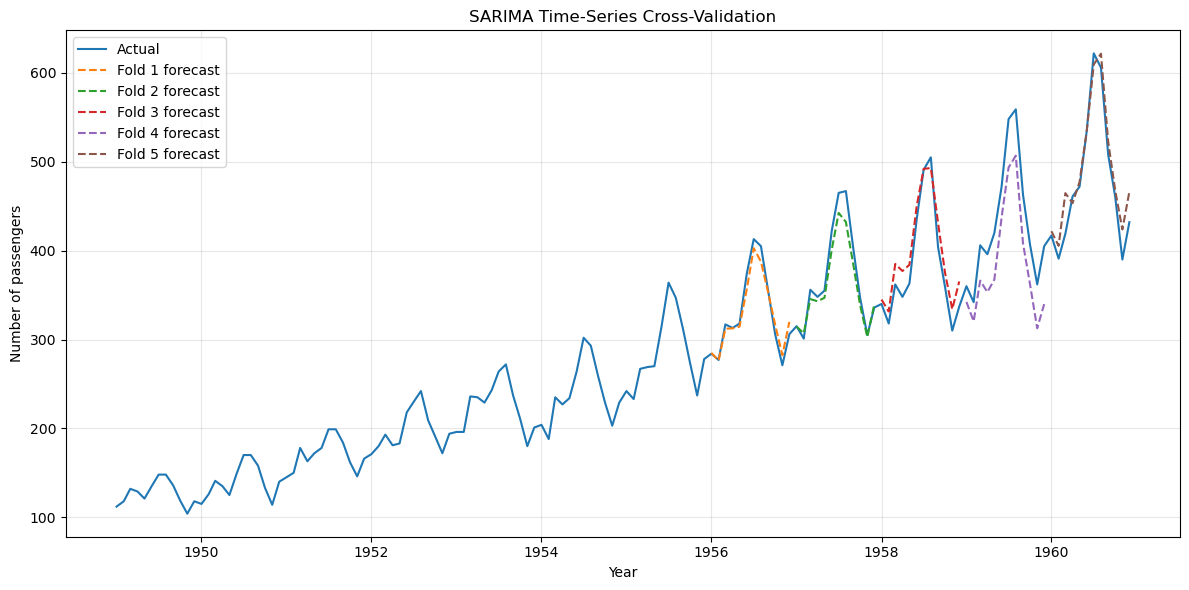

In [18]:
# plot CV forecasts
fig, ax = plt.subplots(figsize=(12, 6))

# plot the complete dataset
ax.plot(
    y.index,
    y,
    label="Actual"
)

# superimpose each CV forecast
for result in fold_results:

    ax.plot(
        result["test"].index,
        result["forecast"],
        linestyle="--",
        label=f"Fold {result['fold']} forecast"
    )


ax.set_title("SARIMA Time-Series Cross-Validation")
ax.set_xlabel("Year")
ax.set_ylabel("Number of passengers")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# tabulate CV results
cv_summary = pd.DataFrame([
    {
        "Fold": result["fold"],
        "Training start": result["train_start"],
        "Training end": result["train_end"],
        "Test start": result["test_start"],
        "Test end": result["test_end"],
        "RMSE": result["rmse"]
    }
    for result in fold_results
])

cv_summary

,Fold,Training start,Training end,Test start,Test end,RMSE
0,1,1949-01-01,1955-12-01,1956-01-01,1956-12-01,9.980822
1,2,1949-01-01,1956-12-01,1957-01-01,1957-12-01,15.348433
2,3,1949-01-01,1957-12-01,1958-01-01,1958-12-01,19.943827
3,4,1949-01-01,1958-12-01,1959-01-01,1959-12-01,46.082737
4,5,1949-01-01,1959-12-01,1960-01-01,1960-12-01,21.189382
